# Matplotlib 4 - Solutions

> **MLCourse · Data Science Foundations · 03_matplotlib**

Worked solutions for the 12 challenges. Compare against your attempt - there are
always several valid ways; check that every checklist item is satisfied.

In [1]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

np.random.seed(42)
plt.rcParams["figure.dpi"] = 100

def new_ax(w=8, h=4):
    fig, ax = plt.subplots(figsize=(w, h))
    return fig, ax

### Solution 1 - Revenue trends with a recession band

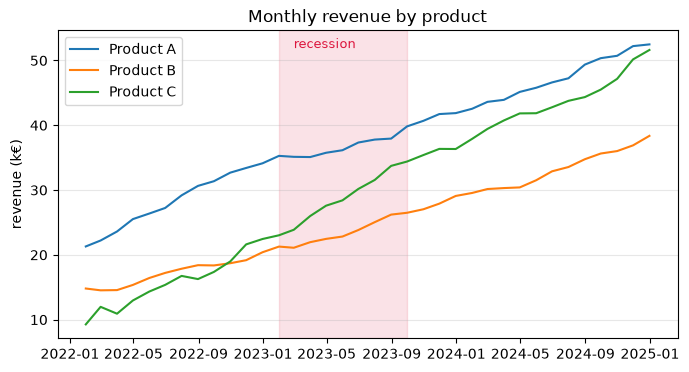

In [2]:
months = pd.date_range("2022-01", periods=36, freq="ME")
prod_A = np.cumsum(np.random.normal(1.0, 0.6, 36)) + 20
prod_B = np.cumsum(np.random.normal(0.7, 0.5, 36)) + 14
prod_C = np.cumsum(np.random.normal(1.3, 0.9, 36)) + 8

fig, ax = new_ax()
ax.plot(months, prod_A, color="tab:blue", label="Product A")
ax.plot(months, prod_B, color="tab:orange", label="Product B")
ax.plot(months, prod_C, color="tab:green", label="Product C")

# Recession: months 12..20 -> shade full height with axvspan
ax.axvspan(months[12], months[20], color="crimson", alpha=0.12)
ax.text(months[13], ax.get_ylim()[1]*0.95, "recession", color="crimson", fontsize=9)

ax.set_title("Monthly revenue by product")
ax.set_ylabel("revenue (k€)")
ax.grid(axis="y", alpha=0.3)
ax.legend()
plt.show()

### Solution 2 - Grouped AND stacked bars

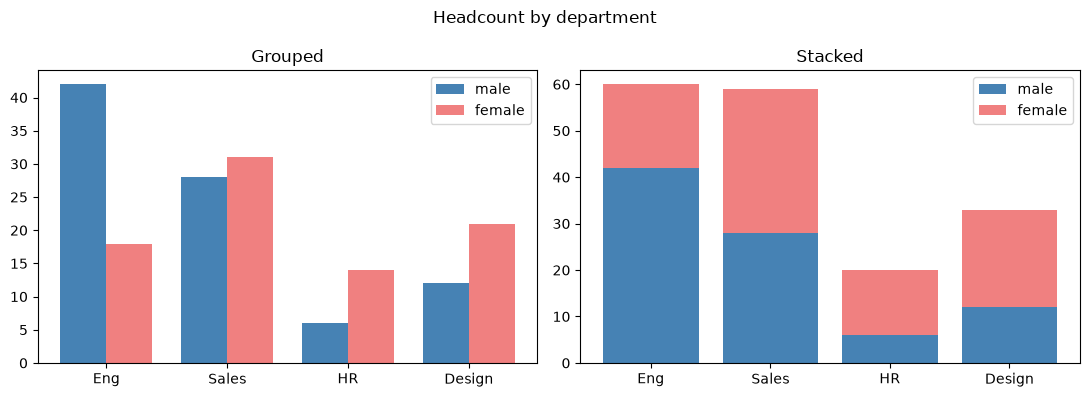

In [3]:
departments = ["Eng", "Sales", "HR", "Design"]
male   = np.array([42, 28, 6, 12])
female = np.array([18, 31, 14, 21])

xpos = np.arange(len(departments))
w = 0.38

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].bar(xpos - w/2, male,   w, label="male",   color="steelblue")   # left offset
axes[0].bar(xpos + w/2, female, w, label="female", color="lightcoral") # right offset
axes[0].set_xticks(xpos, departments)
axes[0].set_title("Grouped")

axes[1].bar(xpos, male, label="male", color="steelblue")
axes[1].bar(xpos, female, bottom=male, label="female", color="lightcoral")  # stack on top
axes[1].set_xticks(xpos, departments)
axes[1].set_title("Stacked")

for ax in axes:
    ax.legend()
fig.suptitle("Headcount by department")
fig.tight_layout()
plt.show()

### Solution 3 - Overlaid step histograms

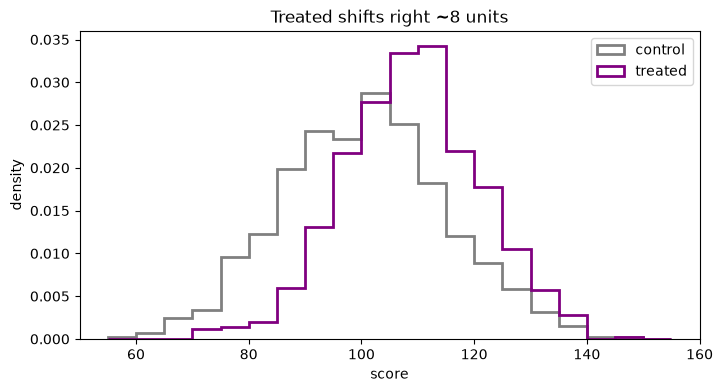

In [4]:
group_control = np.random.normal(100, 15, 900)
group_treated = np.random.normal(108, 12, 700)

bins = np.arange(55, 160, 5)                       # SAME edges for both = fair compare
fig, ax = new_ax()
ax.hist(group_control, bins=bins, density=True, histtype="step", lw=2,
        label="control", color="gray")
ax.hist(group_treated, bins=bins, density=True, histtype="step", lw=2,
        label="treated", color="purple")
ax.set_title("Treated shifts right ~8 units")
ax.set_xlabel("score"); ax.set_ylabel("density")
ax.legend()
plt.show()

### Solution 4 - Labeled scatter of cities

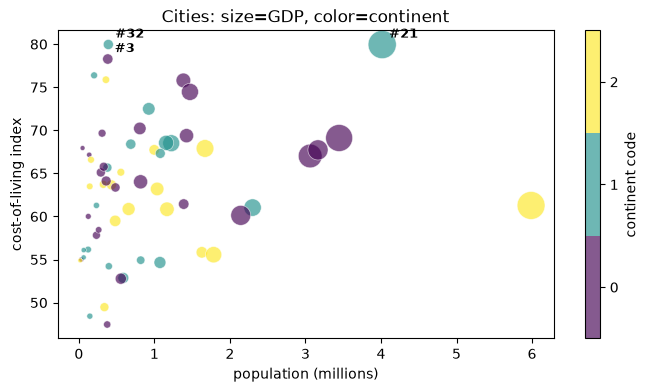

In [5]:
n = 60
population = np.random.lognormal(13, 1.2, n)
cost_index = 40 + 30 * np.log10(population) / np.log10(population.max()) \
             + np.random.normal(0, 8, n)
gdp       = population * np.random.uniform(20, 80, n)
continent = np.random.choice([0, 1, 2], n)

cmap = plt.get_cmap("viridis", 3)                  # discrete 3-color version

fig, ax = new_ax()
sc = ax.scatter(population / 1e6, cost_index,          # millions for readable axis
                s=gdp / gdp.max() * 400 + 10,         # size ∝ GDP, floor of 10pt
                c=continent, cmap=cmap, vmin=-0.5, vmax=2.5,  # centers on integers
                alpha=0.65, edgecolors="white", linewidths=0.5)
fig.colorbar(sc, ticks=[0, 1, 2], label="continent code")

top3 = np.argsort(cost_index)[-3:]                 # indices of 3 most expensive
for i in top3:
    ax.annotate(f"#{i}", xy=(population[i]/1e6, cost_index[i]),
                xytext=(5, 5), textcoords="offset points",
                fontsize=9, fontweight="bold")

ax.set_title("Cities: size=GDP, color=continent")
ax.set_xlabel("population (millions)")
ax.set_ylabel("cost-of-living index")
plt.show()

### Solution 5 - Dual-axis weather dashboard

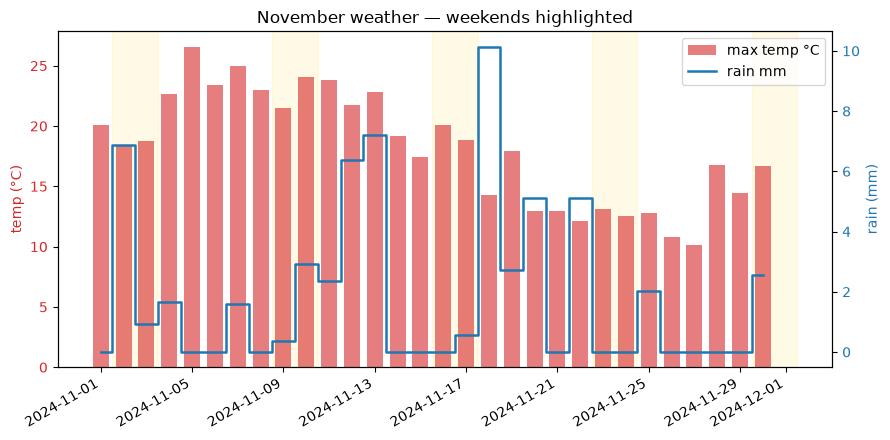

In [6]:
days = pd.date_range("2024-11-01", periods=30)
tmax = 18 + 6*np.sin(np.arange(30)/30*2*np.pi) + np.random.normal(0, 2, 30)
rain = np.abs(np.random.gamma(1.2, 2.0, 30)) * (np.random.rand(30) < 0.5)

fig, ax_t = new_ax(9, 4.5)

ax_t.bar(days, tmax, width=0.7, color="tab:red", alpha=0.6, label="max temp °C")
ax_t.set_ylabel("temp (°C)", color="tab:red")
ax_t.tick_params(axis="y", labelcolor="tab:red")

ax_r = ax_t.twinx()
ax_r.plot(days, rain, color="tab:blue", lw=1.8, drawstyle="steps-mid", label="rain mm")
ax_r.set_ylabel("rain (mm)", color="tab:blue")
ax_r.tick_params(axis="y", labelcolor="tab:blue")

# Shade each Saturday+Sunday pair:
for i, d in enumerate(days):
    if d.dayofweek == 5:                            # Saturday
        ax_t.axvspan(d - pd.Timedelta(hours=12), d + pd.Timedelta(days=1, hours=12),
                     color="gold", alpha=0.10, zorder=0)

h1,l1 = ax_t.get_legend_handles_labels(); h2,l2 = ax_r.get_legend_handles_labels()
ax_t.legend(h1+h2, l1+l2, loc="upper right")
ax_t.set_title("November weather - weekends highlighted")
fig.autofmt_xdate()                                  # tilt date labels
fig.tight_layout()
plt.show()

### Solution 6 - 2×2 mosaic mini-dashboard

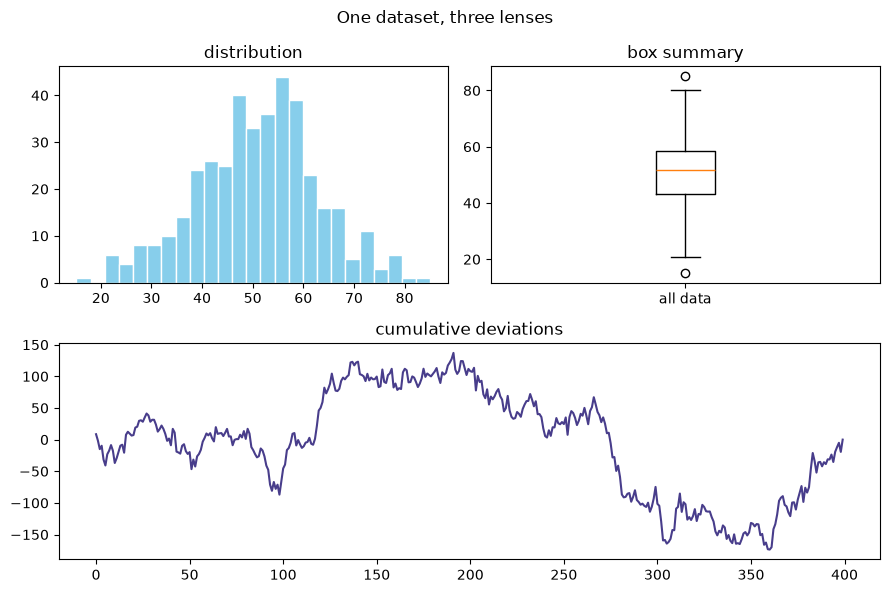

In [7]:
data_dash = np.random.normal(50, 12, 400)

fig, m = plt.subplot_mosaic(
    [["A", "B"],
     ["C", "C"]],               # C spans both columns on bottom row
    figsize=(9, 6),
)

m["A"].hist(data_dash, bins=25, color="skyblue", edgecolor="white")
m["A"].set_title("distribution")

m["B"].boxplot(data_dash, tick_labels=["all data"])
m["B"].set_title("box summary")

m["C"].plot(np.cumsum(data_dash - data_dash.mean()), color="darkslateblue")
m["C"].set_title("cumulative deviations")

fig.suptitle("One dataset, three lenses")
fig.tight_layout()
plt.show()

### Solution 7 - Heatmap with custom ticks

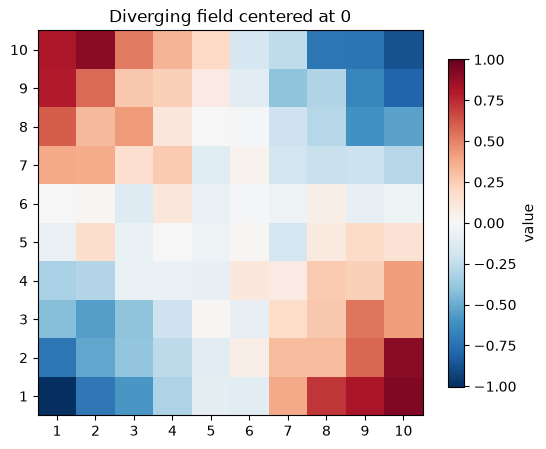

In [8]:
matrix = np.outer(np.linspace(-1, 1, 10), np.linspace(1, -1, 10)) \
         + np.random.normal(0, 0.08, (10, 10))

lim = np.abs(matrix).max()                         # symmetric limits center zero

fig, ax = new_ax(6.4, 5)
im = ax.imshow(matrix, origin="lower",             # row 0 at BOTTOM
               cmap="RdBu_r", vmin=-lim, vmax=lim)
fig.colorbar(im, ax=ax, shrink=0.85, label="value")

ticks = np.arange(10)
ax.set_xticks(ticks, ticks + 1)                    # human numbering 1..10
ax.set_yticks(ticks, ticks + 1)
ax.set_title("Diverging field centered at 0")
plt.show()

### Solution 8 - Forecast with uncertainty cone

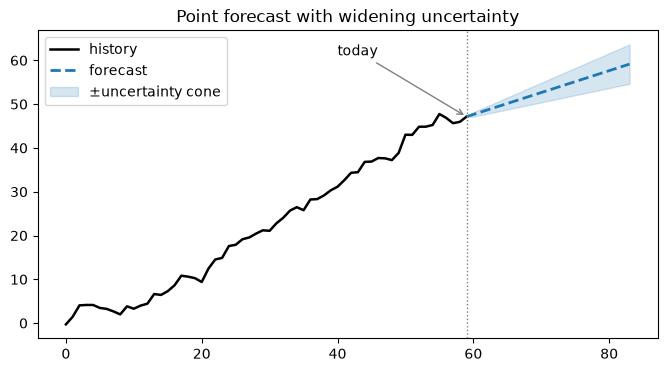

In [9]:
history = np.cumsum(np.random.normal(0.4, 1.2, 60))
forecast = history[-1] + np.arange(1, 25) * 0.5
uncert = np.linspace(0.5, 4.5, 24)

x_hist = np.arange(60)
x_fcst = np.arange(59, 60 + len(forecast))          # anchor + each forecast step

fig, ax = new_ax()
ax.plot(x_hist, history, "-", color="black", lw=1.8, label="history")
fcst_curve = np.r_[history[-1], forecast]           # start today, then forecast
ax.plot(x_fcst, fcst_curve, "--", color="tab:blue", lw=2, label="forecast")
band_lo = np.r_[history[-1], forecast - uncert]
band_hi = np.r_[history[-1], forecast + uncert]
ax.fill_between(x_fcst, band_lo, band_hi, color="tab:blue", alpha=0.18,
                label="±uncertainty cone")

today_x = 59
ax.axvline(today_x, color="gray", ls=":", lw=1)
ax.annotate("today", xy=(today_x, history[-1]), xytext=(40, history[-1]+14),
            arrowprops=dict(arrowstyle="->", color="gray"))
ax.legend(loc="upper left")
ax.set_title("Point forecast with widening uncertainty")
plt.show()

### Solution 9 - Power law on log-log with fit

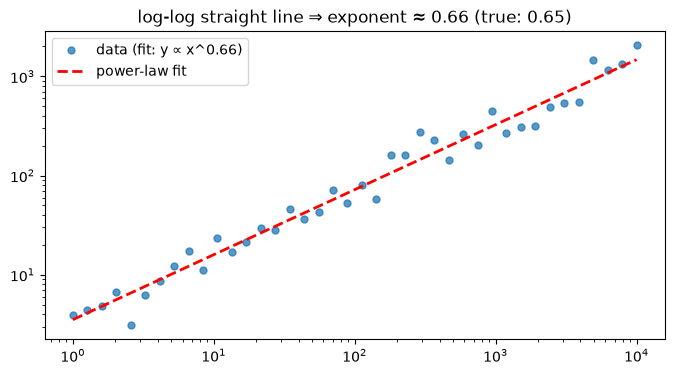

In [10]:
xx = np.geomspace(1, 1e4, 40)
yy = 3.5 * xx**0.65 * np.exp(np.random.normal(0, .25, 40))

b_fit, a_fit = np.polyfit(np.log10(xx), np.log10(yy), 1)   # log-space linear fit

xs_line = np.geomspace(xx.min(), xx.max(), 100)
ys_line = 10**a_fit * xs_line**b_fit                        # invert: y = A·x^b

fig, ax = new_ax()
ax.loglog(xx, yy, "o", ms=5, alpha=0.75, label=f"data (fit: y ∝ x^{b_fit:.2f})")
ax.loglog(xs_line, ys_line, "r--", lw=2, label="power-law fit")
ax.set_title(f"log-log straight line ⇒ exponent ≈ {b_fit:.2f} (true: 0.65)")
ax.legend()
plt.show()

### Solution 10 - 3-D surface with camera control

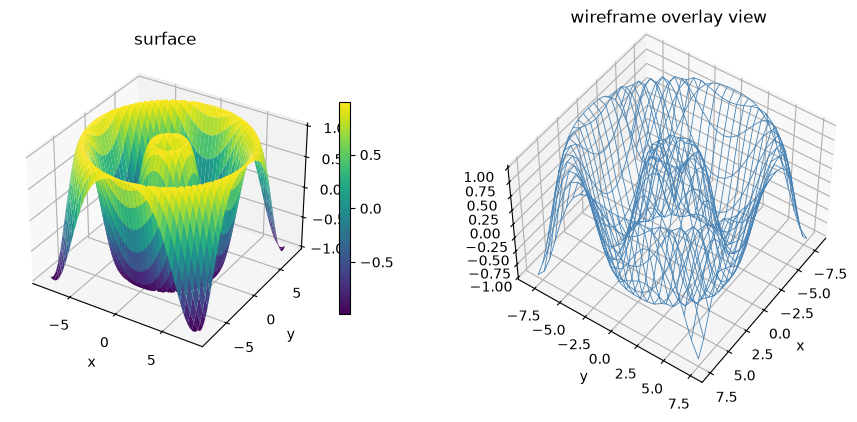

In [11]:
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

gx = np.linspace(-8, 8, 120); gy = np.linspace(-8, 8, 120)
XG, YG = np.meshgrid(gx, gy)
ZG = np.sin(np.sqrt(XG**2 + YG**2))

fig = plt.figure(figsize=(11, 4.6))

ax1 = fig.add_subplot(121, projection="3d")
surf = ax1.plot_surface(XG, YG, ZG, cmap="viridis", linewidth=0, antialiased=True)
fig.colorbar(surf, ax=ax1, shrink=0.6)
ax1.view_init(elev=32, azim=-58)
ax1.set_title("surface")

ax2 = fig.add_subplot(122, projection="3d")
wire = ax2.plot_wireframe(XG[::5, ::5], YG[::5, ::5], ZG[::5, ::5],
                          color="steelblue", lw=0.6)
ax2.view_init(elev=48, azim=35)
ax2.set_title("wireframe overlay view")

for a in (ax1, ax2):
    a.set_xlabel("x"); a.set_ylabel("y")
plt.show()

### Solution 11 - Candlestick-style OHLC

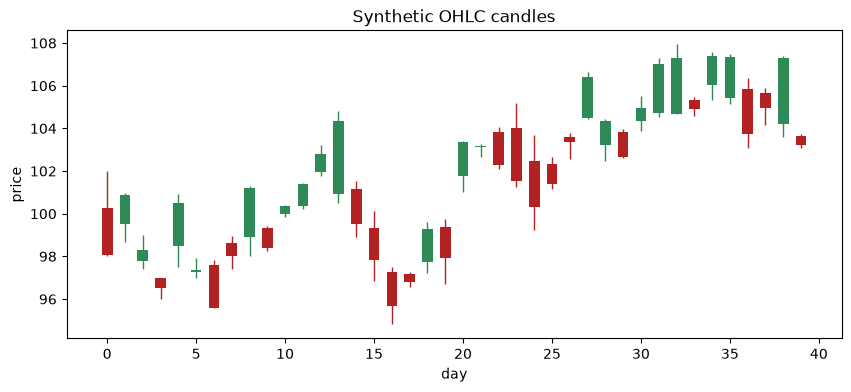

In [12]:
ohlc = pd.DataFrame({"open": np.cumsum(np.random.normal(0, 1, 40)) + 100})
ohlc["close"] = ohlc["open"] + np.random.normal(0, 1.4, 40)
ohlc["high"]  = ohlc[["open","close"]].max(axis=1) + np.abs(np.random.normal(0, .6, 40))
ohlc["low"]   = ohlc[["open","close"]].min(axis=1) - np.abs(np.random.normal(0, .6, 40))

up = ohlc["close"] >= ohlc["open"]
colors = np.where(up, "seagreen", "firebrick")

fig, ax = new_ax(10, 4)
xs = np.arange(len(ohlc))

# Wicks: thin vertical lines low→high:
ax.vlines(xs, ohlc["low"], ohlc["high"], color=colors, lw=1)
# Bodies: thick bars open→close:
ax.bar(xs, (ohlc["close"] - ohlc["open"]).abs().replace(0, 0.02),
       bottom=np.minimum(ohlc["open"], ohlc["close"]),
       width=0.6, color=colors, zorder=3)

ax.set_title("Synthetic OHLC candles")
ax.set_xlabel("day"); ax.set_ylabel("price")
plt.show()

### Solution 12 - Sparklines row

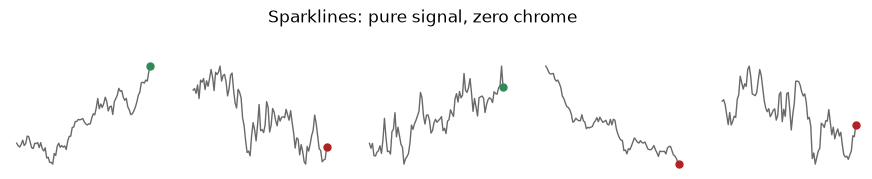

In [13]:
walks = [np.cumsum(np.random.randn(90)) for _ in range(5)]

fig, axes = plt.subplots(1, 5, figsize=(11, 1.4))

for ax, walk in zip(axes, walks):
    ax.plot(walk, lw=1, color="dimgray")            # the line only...
    up_day = walk[-1] >= walk[0]
    end_color = "seagreen" if up_day else "firebrick"
    ax.plot(len(walk)-1, walk[-1], "o", color=end_color, ms=5)  # direction dot
    ax.set_xticks([]); ax.set_yticks([])            # strip ALL ticks
    for spine in ax.spines.values():                # ...and all borders
        spine.set_visible(False)

fig.suptitle("Sparklines: pure signal, zero chrome", y=1.25)
plt.show()

---
## Reflection checklist

- Could you rebuild any of these from memory?
- Which solution used a trick you hadn't tried (e.g., `np.minimum` for candle
  bottoms, `get_cmap(n)` for discrete colors)?
- Where did YOU over-decorate? Compare ink-to-information ratio honestly.